**IMPORT LIBRARIES**

In [81]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from mlxtend.plotting import plot_confusion_matrix
import pickle
from collections import Counter
from imblearn.over_sampling import SMOTE

**LOADING THE DATA**

In [82]:
churn = pd.read_csv("Bank Customer Churn Prediction.csv")
churn

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,15606229,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,15569892,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,15584532,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,15682355,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


**DATA PREPROCESSING AND EXPLORATORY DATA ANALYSIS**

In [83]:
churn.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  str    
 3   gender            10000 non-null  str    
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  
 8   credit_card       10000 non-null  int64  
 9   active_member     10000 non-null  int64  
 10  estimated_salary  10000 non-null  float64
 11  churn             10000 non-null  int64  
dtypes: float64(2), int64(8), str(2)
memory usage: 1.0 MB


In [84]:
## checking for missing values
churn.isnull().sum()

customer_id         0
credit_score        0
country             0
gender              0
age                 0
tenure              0
balance             0
products_number     0
credit_card         0
active_member       0
estimated_salary    0
churn               0
dtype: int64

In [85]:
## encoding categorical variables to numerical values
## label encoder will be used 
le = LabelEncoder()
churn['gender'] = le.fit_transform(churn['gender'])
churn['country'] = le.fit_transform(churn['country'])




In [86]:
## dataset after encoding
churn.head()

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,0,0,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,2,0,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,0,0,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,0,0,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,2,0,43,2,125510.82,1,1,1,79084.10,0


In [87]:
## dropping the customer_id column
churn = churn.drop('customer_id', axis = 1)

In [88]:
corr_mat = churn.corr()
corr_mat

,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
credit_score,1.000000,0.007888,-0.002857,-0.003965,0.000842,0.006268,0.012238,-0.005458,0.025651,-0.001384,-0.027094
country,0.007888,1.000000,0.004719,0.022812,0.003739,0.069408,0.003972,-0.008523,0.006724,-0.001369,0.035943
gender,-0.002857,0.004719,1.000000,-0.027544,0.014733,0.012087,-0.021859,0.005766,0.022544,-0.008112,-0.106512
age,-0.003965,0.022812,-0.027544,1.000000,-0.009997,0.028308,-0.030680,-0.011721,0.085472,-0.007201,0.285323
tenure,0.000842,0.003739,0.014733,-0.009997,1.000000,-0.012254,0.013444,0.022583,-0.028362,0.007784,-0.014001
balance,0.006268,0.069408,0.012087,0.028308,-0.012254,1.000000,-0.304180,-0.014858,-0.010084,0.012797,0.118533
products_number,0.012238,0.003972,-0.021859,-0.030680,0.013444,-0.304180,1.000000,0.003183,0.009612,0.014204,-0.047820
credit_card,-0.005458,-0.008523,0.005766,-0.011721,0.022583,-0.014858,0.003183,1.000000,-0.011866,-0.009933,-0.007138
active_member,0.025651,0.006724,0.022544,0.085472,-0.028362,-0.010084,0.009612,-0.011866,1.000000,-0.011421,-0.156128
estimated_salary,-0.001384,-0.001369,-0.008112,-0.007201,0.007784,0.012797,0.014204,-0.009933,-0.011421,1.000000,0.012097


<Axes: >

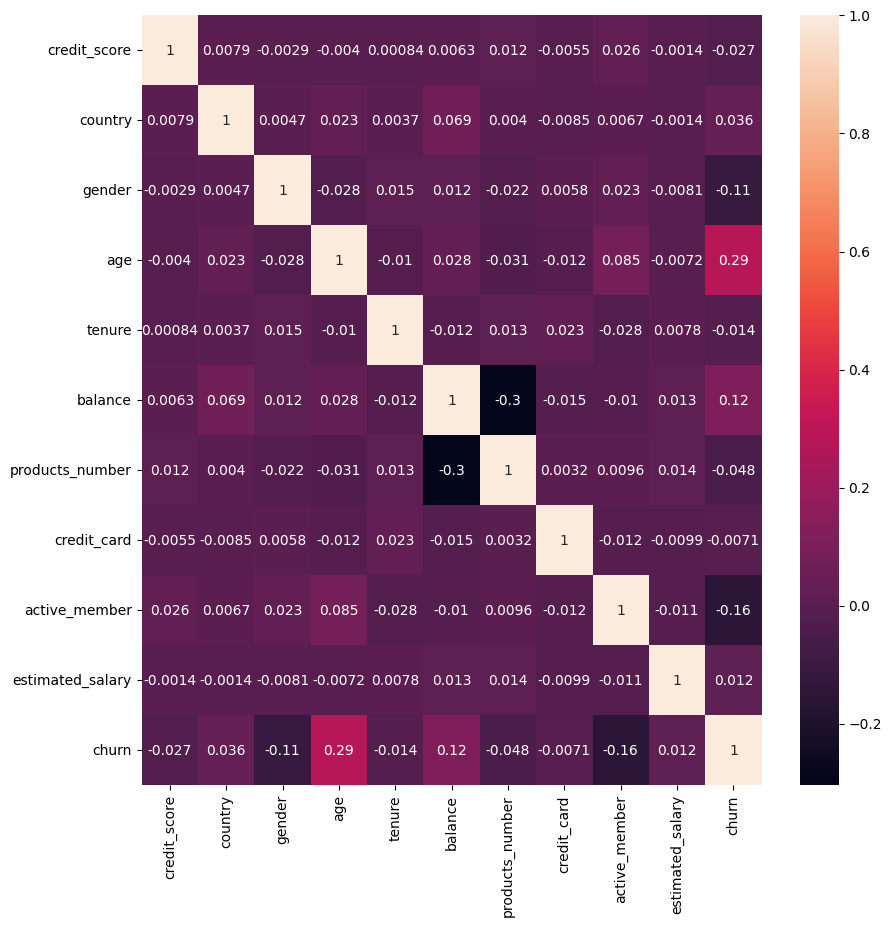

In [89]:
## plotting heatmap to find correlation between the different variable
plt.figure(figsize= (10,10))
sns.heatmap(corr_mat, annot = True)

In [90]:
## creating a new column and replacing numerical value with categorical value for easy visualization
churn['churn_label'] = churn['churn'].replace({0: 'Not_Churn', 1: 'Churn'})

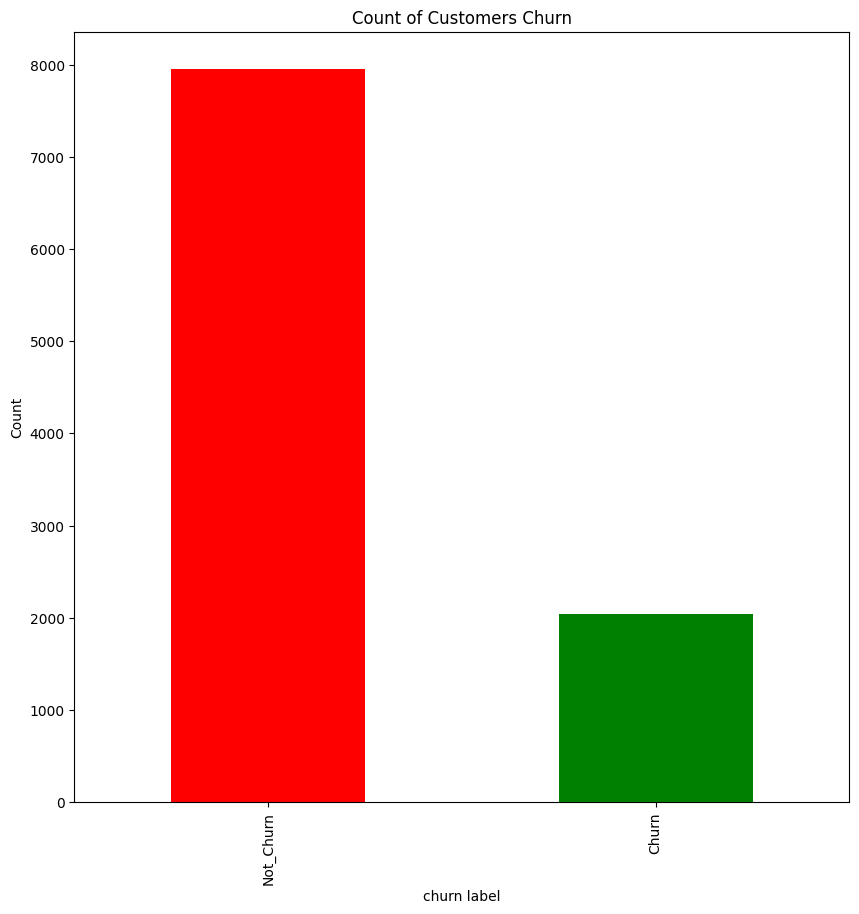

In [91]:
churn_count = churn['churn_label'].value_counts()

## plotting the bar plot
plt.figure(figsize =(10,10))
churn_count.plot(kind = 'bar', width = 0.5, color = ['red', 'green'])
plt.xlabel('churn label')
plt.ylabel('Count')
plt.title('Count of Customers Churn')
plt.show()

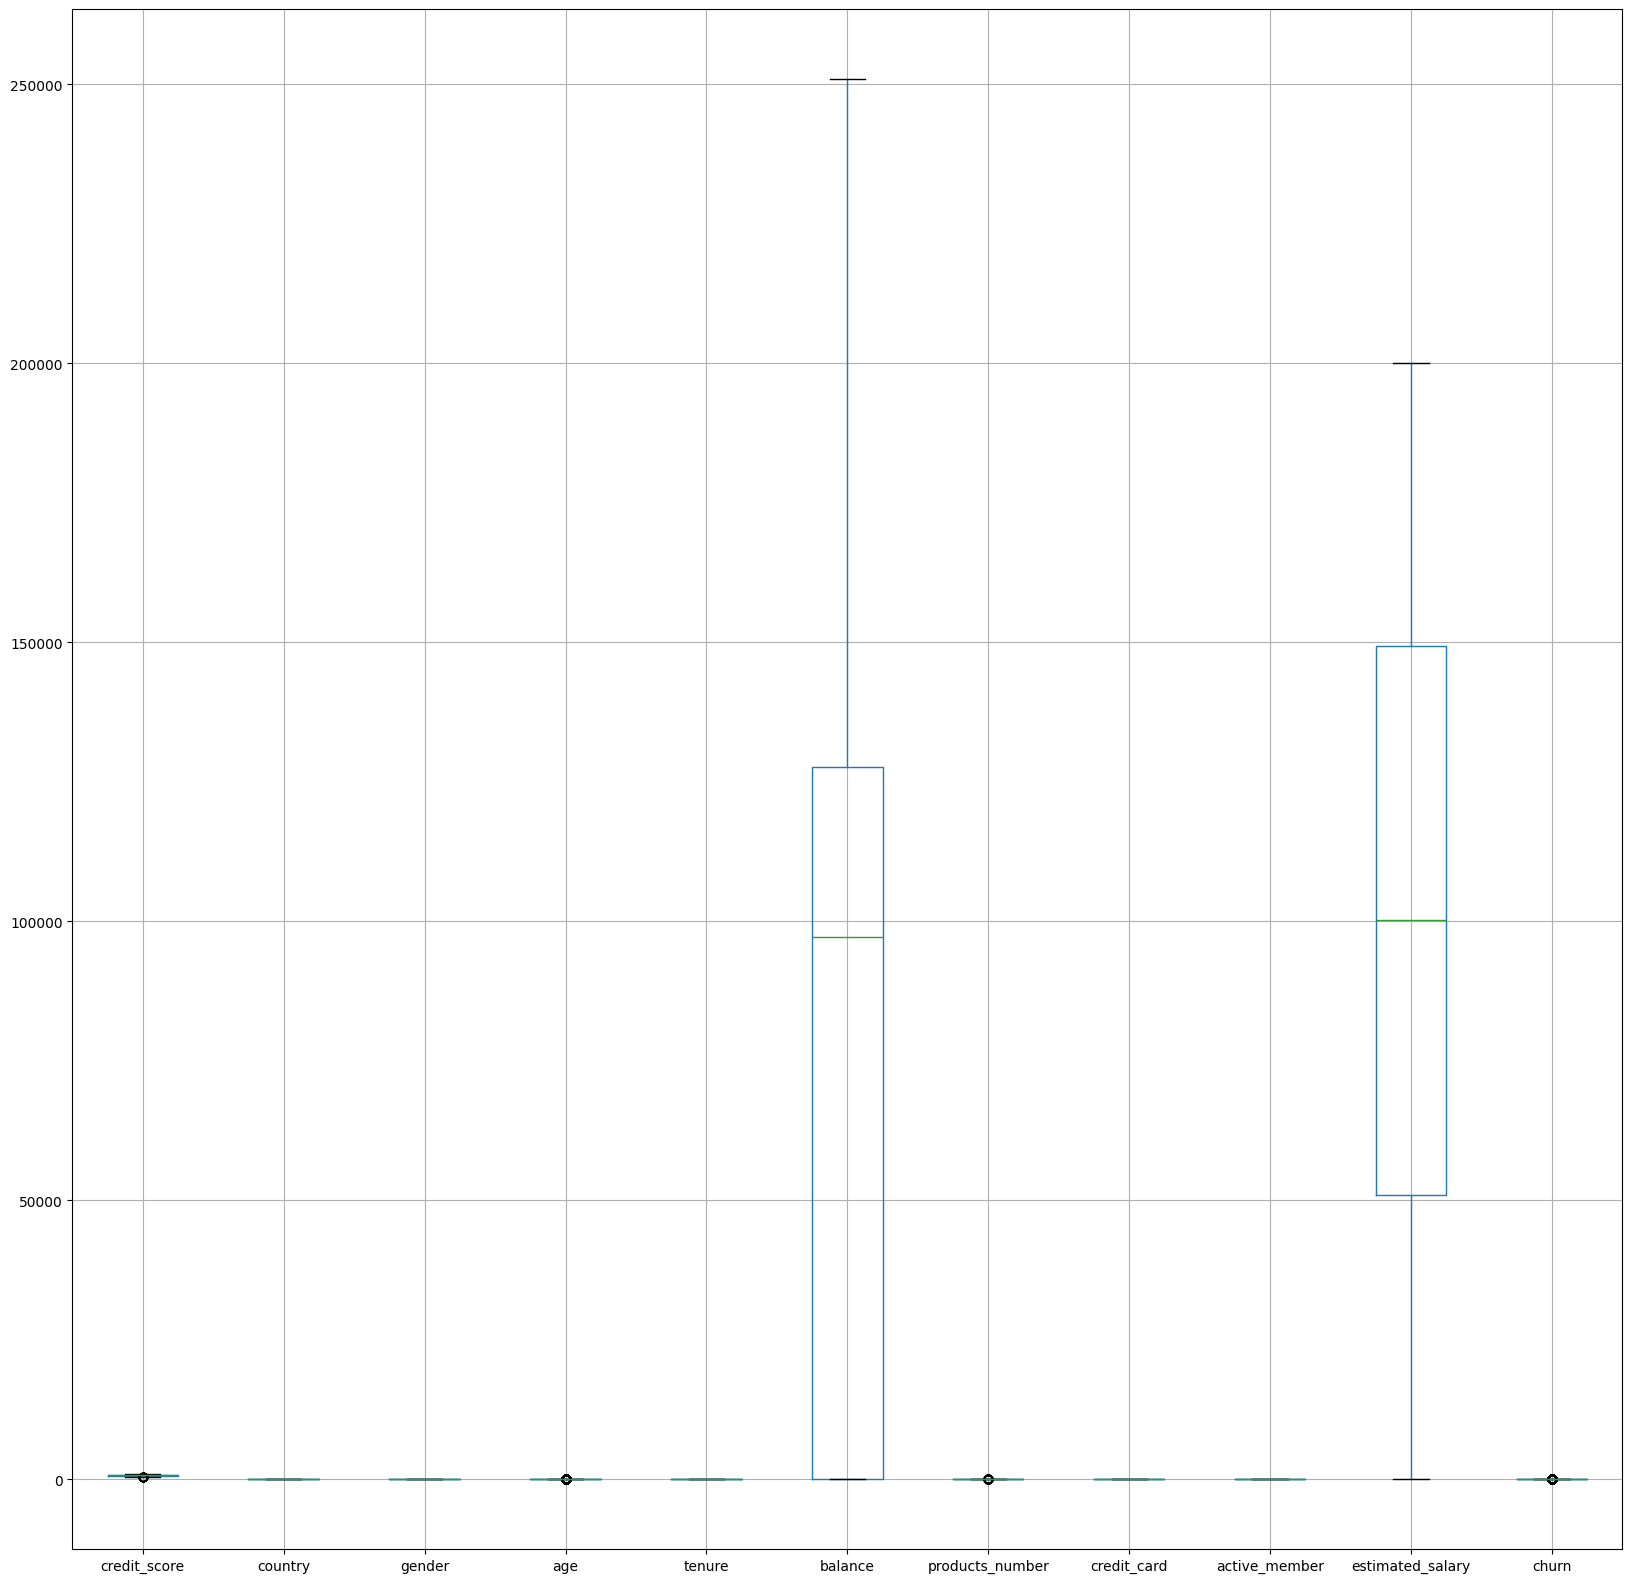

In [92]:
## plotting boxplot to detect the outliers
## the outliers below show outliers in credit score, age, product number and churn column
## churn column shows outliers because it is a case of an imbalanced dataset where not churn has higher label than churn
## so churn outliers will not be replaced with mean but instead will be balanced.
churn.boxplot(figsize=(20, 20))
plt.show()

In [93]:
## dealing with outliers
def replace_outliers_with_mean(col, churn):
    q1, q3 = churn[col].quantile(0.25), churn[col].quantile(0.75)
    iqr = q3 - q1
    ll = q1 - 1.5 * iqr
    ul = q3 + 1.5 * iqr
    churn[col] = np.where(churn[col] > ul, churn[col].mean(), np.where(churn[col] < ll, churn[col].mean(), churn[col]))

columns = ['credit_score', 'age', 'products_number']
for col in columns:
    replace_outliers_with_mean(col, churn)





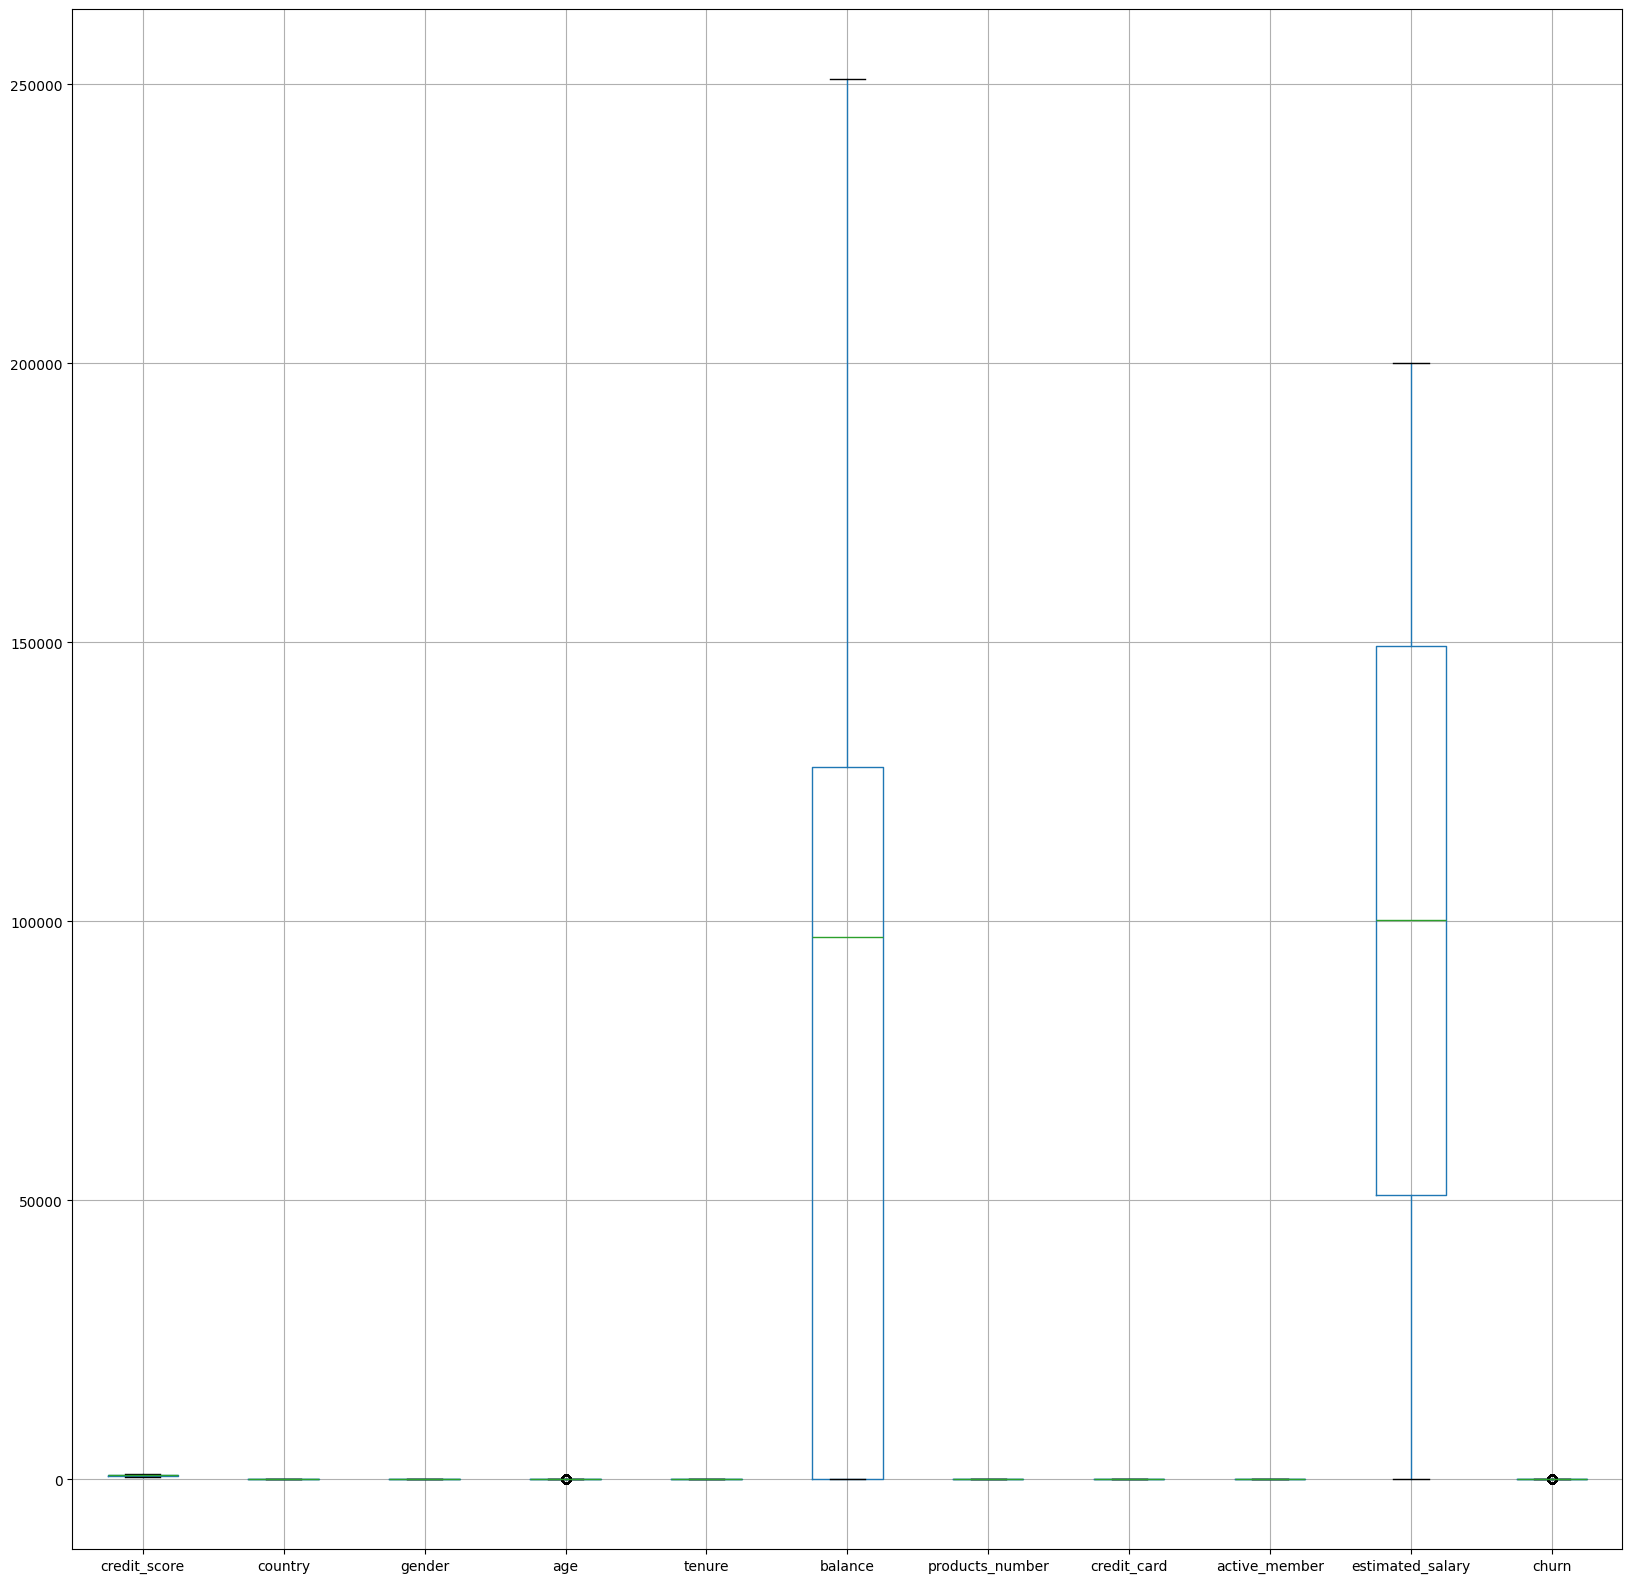

In [94]:
## boxplot after removing outliers
churn.boxplot(figsize=(20, 20))
plt.show()

In [95]:
churn

,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn,churn_label
0,619.0,0,0,42.0,2,0.00,1.0,1,1,101348.88,1,Churn
1,608.0,2,0,41.0,1,83807.86,1.0,0,1,112542.58,0,Not_Churn
2,502.0,0,0,42.0,8,159660.80,3.0,1,0,113931.57,1,Churn
3,699.0,0,0,39.0,1,0.00,2.0,0,0,93826.63,0,Not_Churn
4,850.0,2,0,43.0,2,125510.82,1.0,1,1,79084.10,0,Not_Churn
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771.0,0,1,39.0,5,0.00,2.0,1,0,96270.64,0,Not_Churn
9996,516.0,0,1,35.0,10,57369.61,1.0,1,1,101699.77,0,Not_Churn
9997,709.0,0,0,36.0,7,0.00,1.0,0,1,42085.58,1,Churn
9998,772.0,1,1,42.0,3,75075.31,2.0,1,0,92888.52,1,Churn


In [96]:
## data splitting
X = churn.drop(columns=['churn', 'churn_label'])
y = churn['churn']

**DATA SPLITTING**

In [97]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=32)

**DATA NORMALIZATION**

In [98]:

## MinMaxScaler scales the data between 0 and 1 by subtracting the minimum 
## value in the feature from each data point and dividing it by the range (i.e., the difference between the minimum and maximum values). 
## This is useful when the features have different scales and you want to bring them to the same scale

scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [99]:
## oversampling the minority class of churn to have a balanced dataset (ONLY on training data to avoid data leakage)
smote = SMOTE(random_state=32)
X_train, y_train = smote.fit_resample(X_train, y_train)
print('Training set class distribution after SMOTE:')
print(Counter(y_train))
print('\nTest set class distribution (unchanged):')
print(Counter(y_test))


Training set class distribution after SMOTE:
Counter({0: 6370, 1: 6370})

Test set class distribution (unchanged):
Counter({0: 1593, 1: 407})


**MODEL BUILDING**

In [100]:
model_rf = RandomForestClassifier(n_estimators=100, max_depth = 5)
model_rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_

**SAVING THE MODEL**

In [101]:
# Save both the trained model and the fitted scaler
with open('model.pkl', 'wb') as file:
    pickle.dump(model_rf, file)

with open('scaler.pkl', 'wb') as file:
    pickle.dump(scaler, file)

# Load the model and scaler from disk for inference
with open('model.pkl', 'rb') as file:
    loaded_model = pickle.load(file)

with open('scaler.pkl', 'rb') as file:
    loaded_scaler = pickle.load(file)

In [102]:
## making prediction
y_pred = loaded_model.predict(X_test)
pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})

,Actual,Predicted
8695,0,0
4111,0,0
5843,0,0
3085,1,1
3702,0,0
...,...,...
2566,0,0
2847,1,0
5042,0,0
3102,0,0


**MODEL EVALUATION**

In [103]:
# checking for the model accuracy
print('Accuracy:', accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.787
              precision    recall  f1-score   support

           0       0.91      0.81      0.86      1593
           1       0.48      0.69      0.57       407

    accuracy                           0.79      2000
   macro avg       0.70      0.75      0.71      2000
weighted avg       0.82      0.79      0.80      2000



In [104]:
## confusion matrix
cm = confusion_matrix(y_test, y_pred)

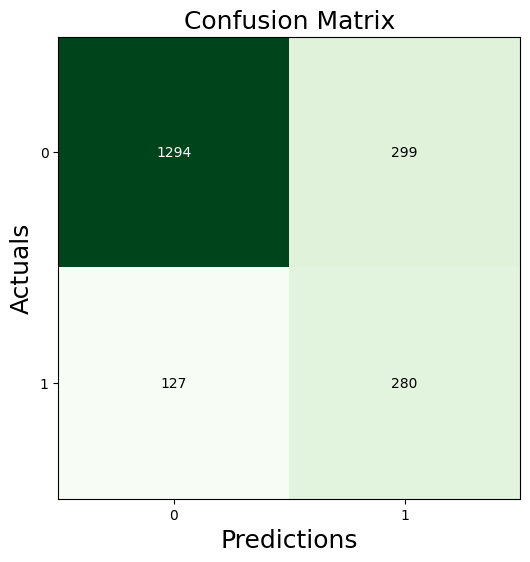

In [105]:
## confusion matrix plot
fig, ax = plot_confusion_matrix(conf_mat=cm, figsize=(6, 6), cmap=plt.cm.Greens)
plt.xlabel('Predictions', fontsize=18)
plt.ylabel('Actuals', fontsize=18)
plt.title('Confusion Matrix', fontsize=18)
plt.show()